# Construct design space with known Kv and Rp

We need a few imports:

In [2]:
from ruamel.yaml import YAML
yaml = YAML()

from lyopronto import design_space, generate_visualizations

In [3]:
# Set up the simulation settings
# This needs to be a dict with string keys, which can be expressed in YAML as well
sim = {
    'tool':'Design Space Generator',
    'Kv_known':'Y',
    'Rp_known':'Y',
    'Variable_Pch':'N',
    'Variable_Tsh':'N'}


# Vial and fill properties
vial = {
    # Av = Vial area in cm^2
    'Av': 3.80,
    # Ap = Product Area in cm^2
    'Ap': 3.14,
    # Vfill = Fill volume in mL
    'Vfill': 2.0
}

In [4]:

# Product properties
product = {
    # cSolid = Fractional concentration of solute in the frozen solution
    'cSolid': 0.05,
    # Product Resistance Parameters
    'R0': 1.4, # cm^2-hr-Torr/g
    'A1': 16.0, # cm-hr-Torr/g
    'A2': 0.0, # 1/cm
    # Critical product temperature
    # At least 2 to 3 deg C below collapse or glass transition temperature
    'T_pr_crit': -15 # in deg C
}


In [18]:
# Vial Heat Transfer Parameters
ht = {
    'KC': 2.75e-4, # cal/s-cm^2-K
    'KP': 8.93e-4, # cal/s-cm^2-K-Torr
    'KD': 0.46     # 1/Torr
}

# Chamber Pressure
Pchamber = {
    # setpt = Chamber pressure evaluation points in Torr
    'setpt': [0.05, 0.1, 0.15],
}

Tshelf = {
    # init = Intial shelf temperature in C
    'init': -35.0,
    # ramp_rate = Shelf temperature ramping rate in C/min
    'ramp_rate': 1.0,
    # setpt = Shelf temperature set points in C
    'setpt': [-15, 0, 30, 90],
}

# Equipment capability (linear fit of sublimation rate vs chamber pressure)
eq_cap = {
    'a': -0.182,  # intercept [kg/hr]
    'b': 11.7     # slope [kg/hr/Torr]
}

# Number of vials
nVial = 2000

# Time step
dt = 0.01    # hr

Now, we are ready to construct the design space, which is `lyopronto.design_space.dry`.

??? info - documentation
    *Here is the docstring for `design_space.dry`:*
    ::: lyopronto.design_space.dry

In [19]:
# Run the design space simulation
ds_shelf, ds_pr, ds_eq_cap = design_space.dry(vial, product, ht, Pchamber, Tshelf, dt, eq_cap, nVial)

In [ ]:
# It's a good idea, particularly when you are exploring interactively, to write the simulation input and output to disk together so that as you do later analysis, you have a record of what you did. Uncommenting the following code will do so.

sim_setup = {
    'sim': sim,
    'vial': vial,
    'product': product,
    'ht': ht,
    'Pchamber': Pchamber,
    'Tshelf': Tshelf,
    'eq_cap': eq_cap,
    'nVial': nVial,
    'dt': dt,
}

# # Write input data to disk as YAML
# import time
# current_time = time.strftime("%Y%m%d_%H%M%S")
# try:
#     yamlfile = open('lyopronto_input_'+current_time+'.yaml', 'w')
#     yaml.dump(sim_setup, yamlfile)
# finally:
#     yamlfile.close()

'Design Space Generator'

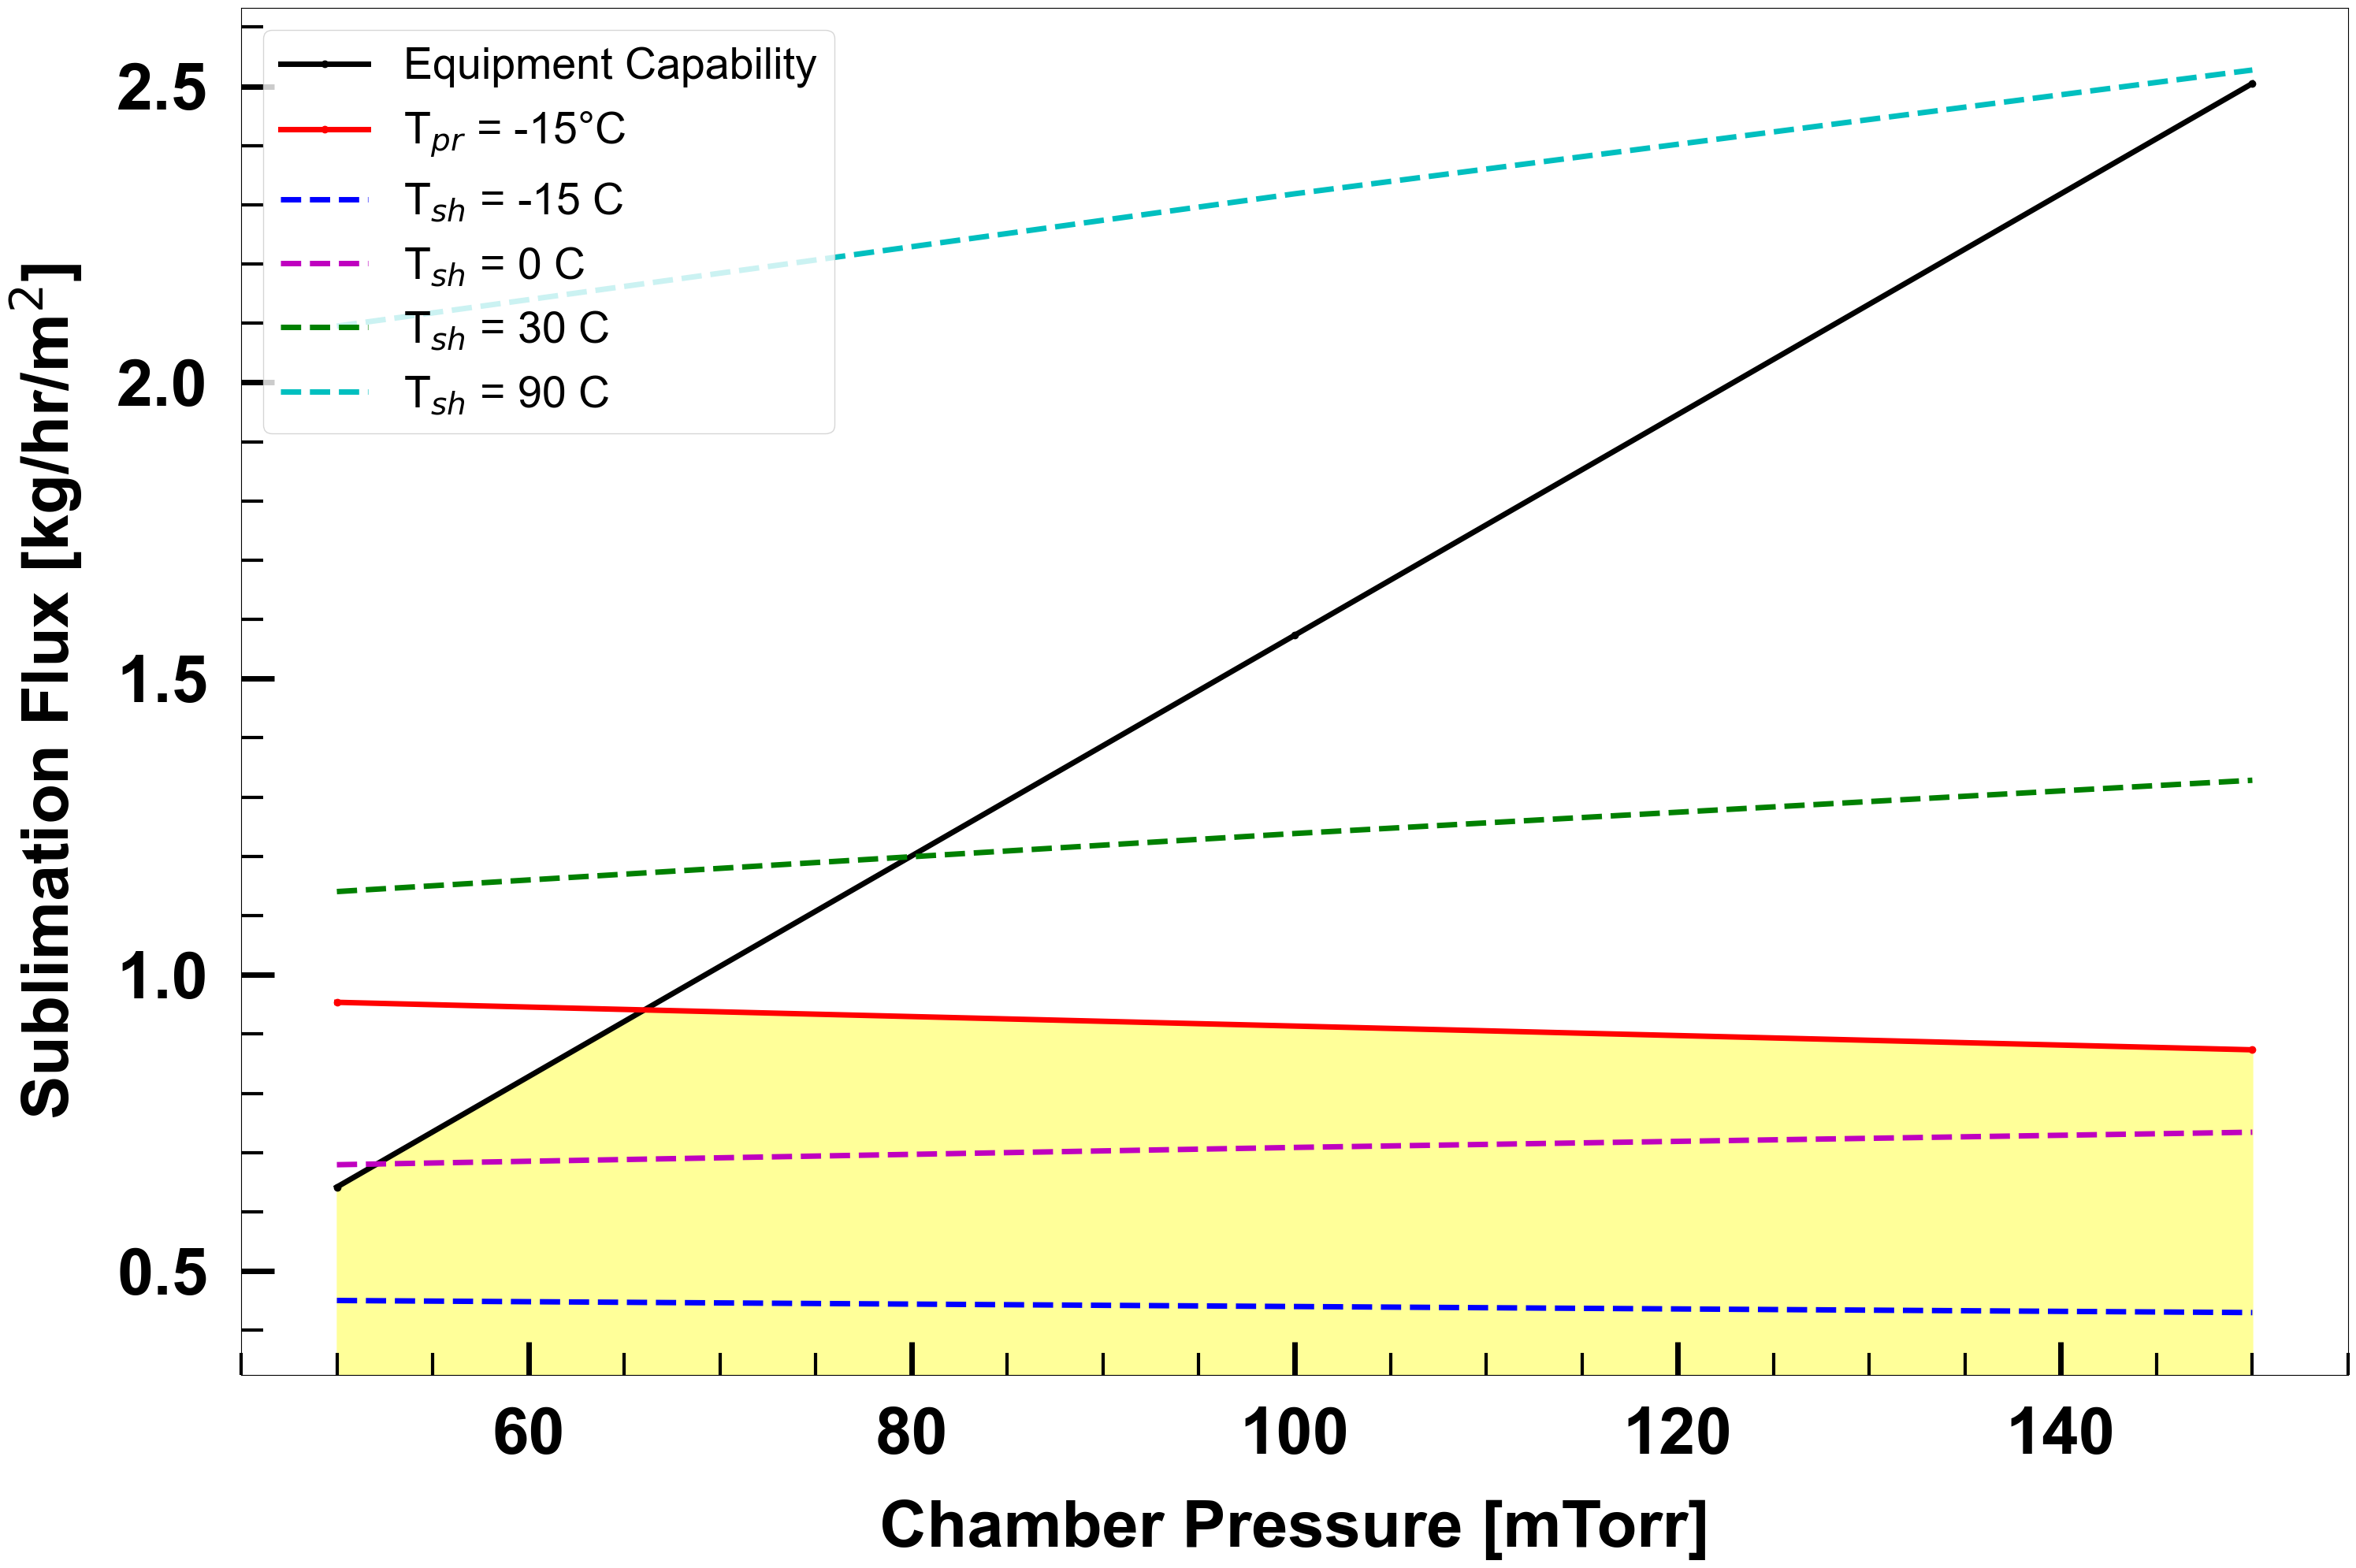

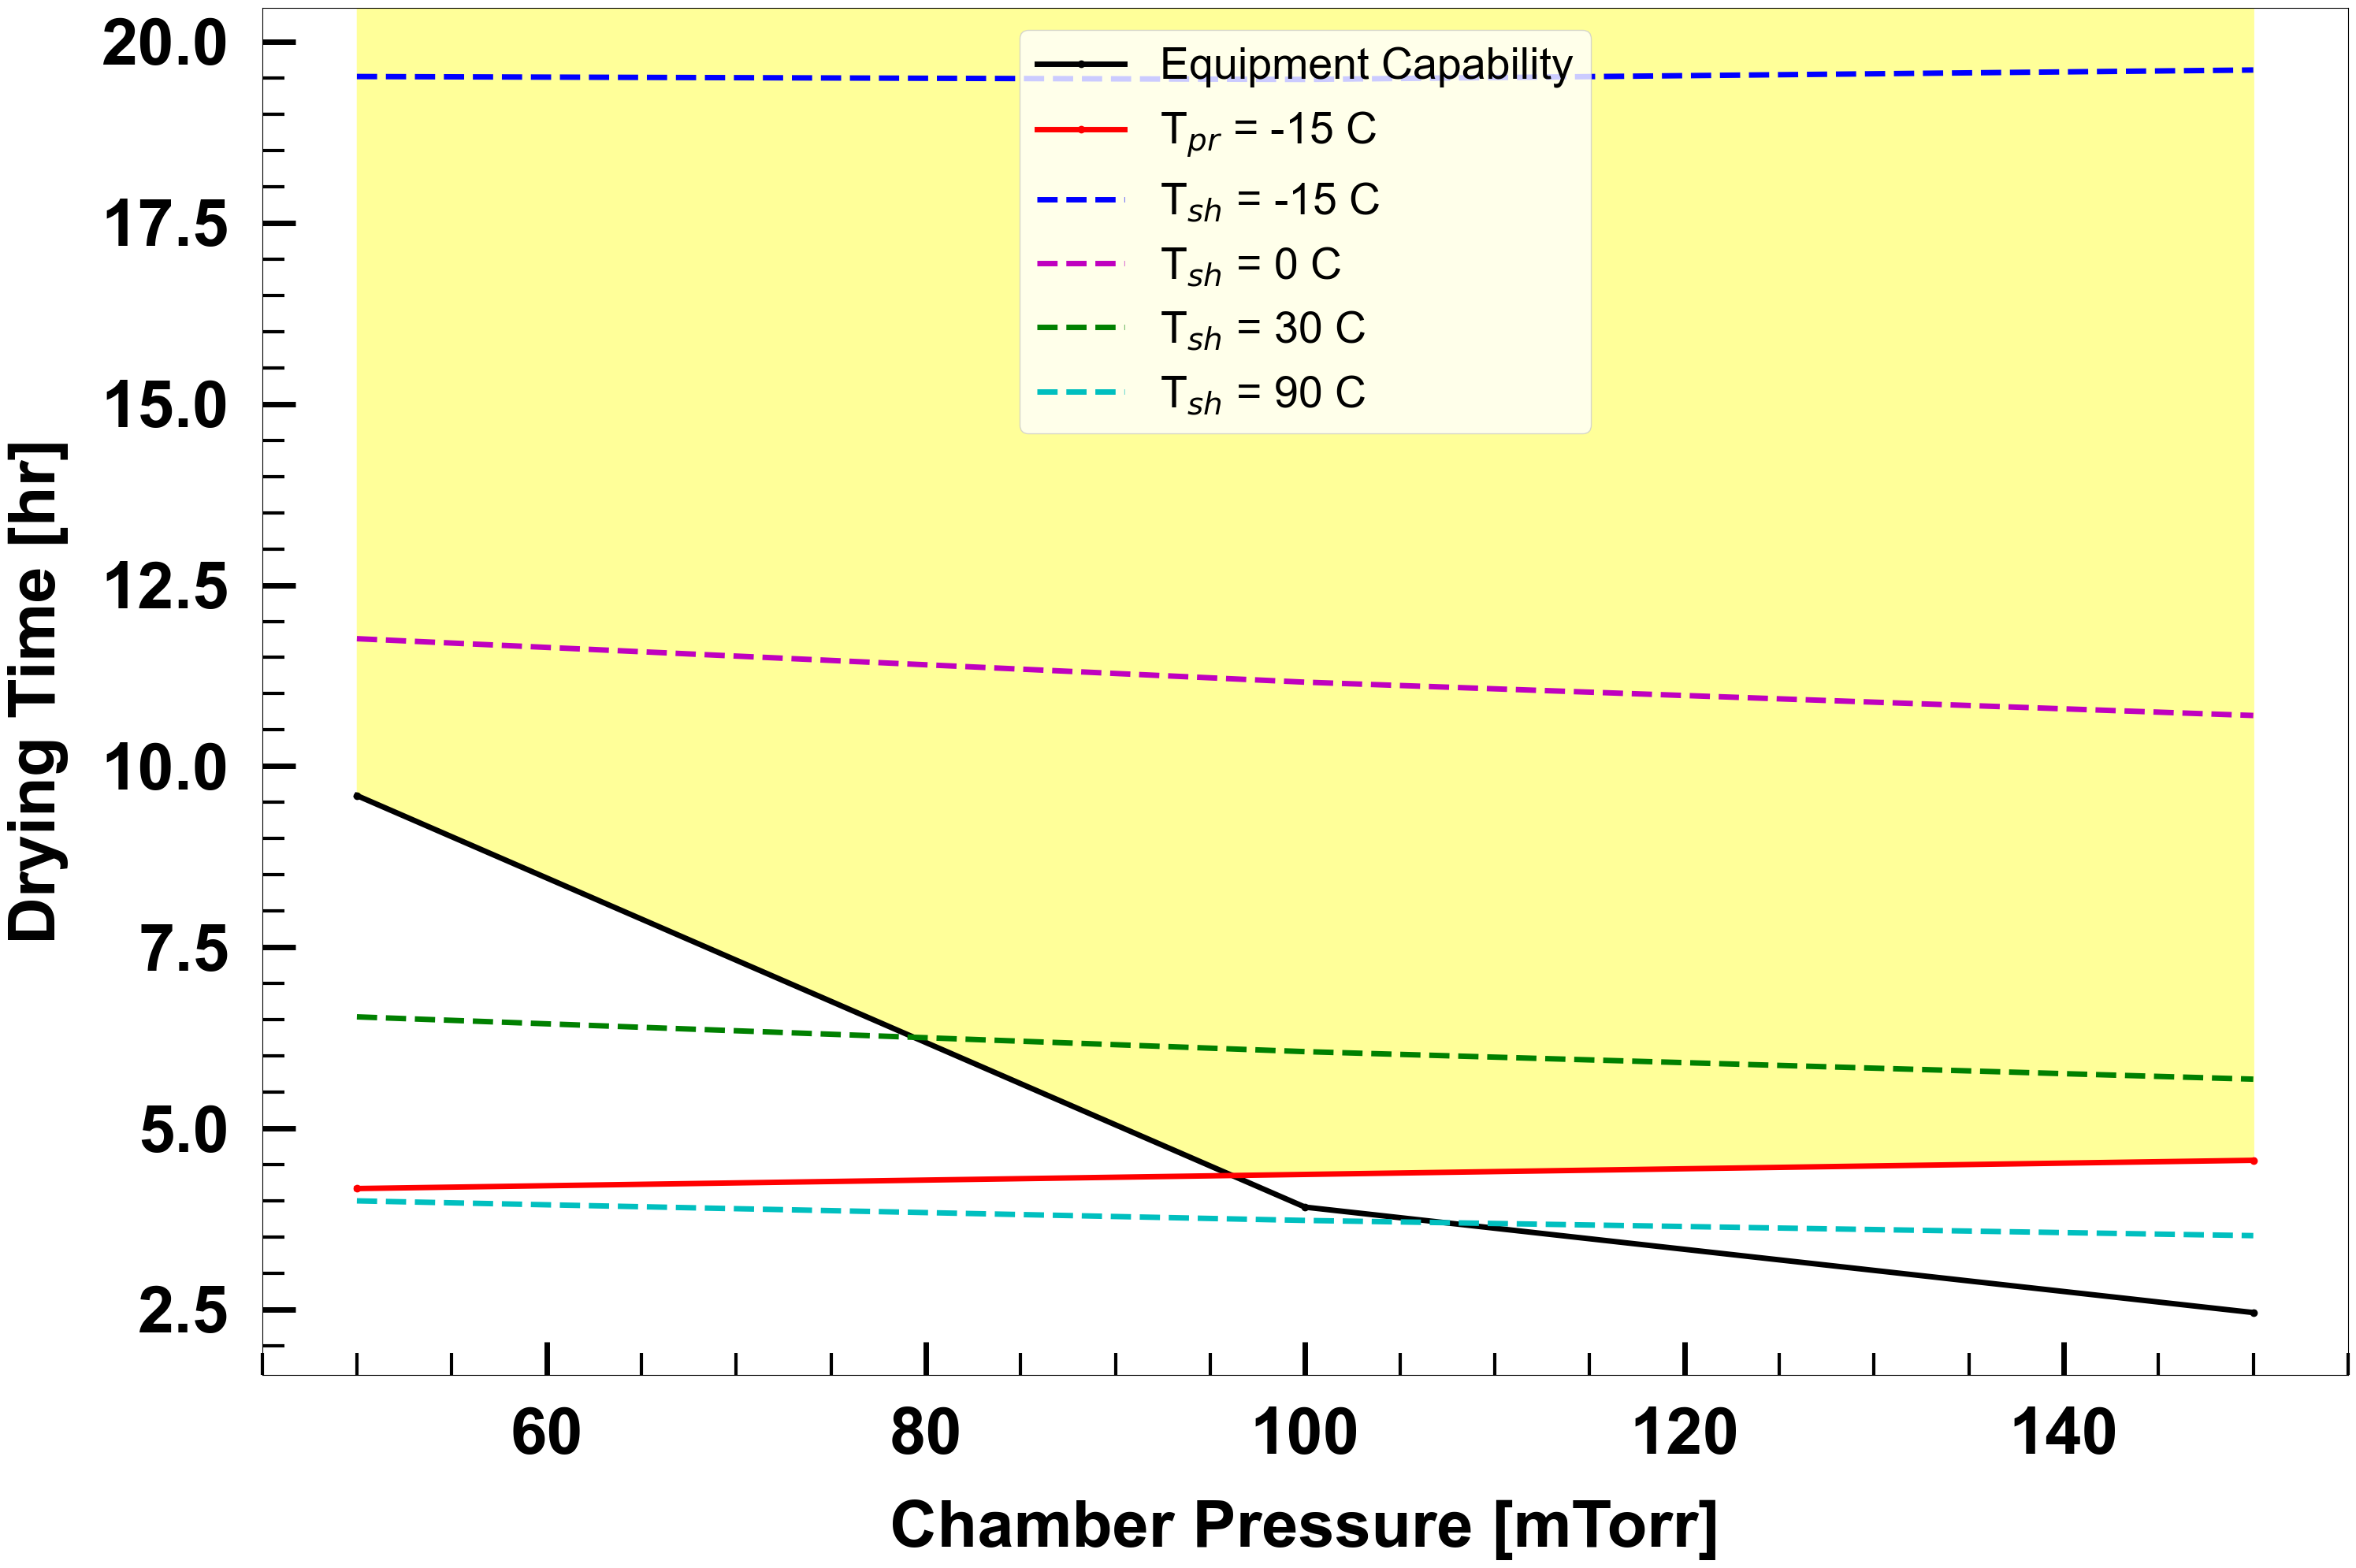

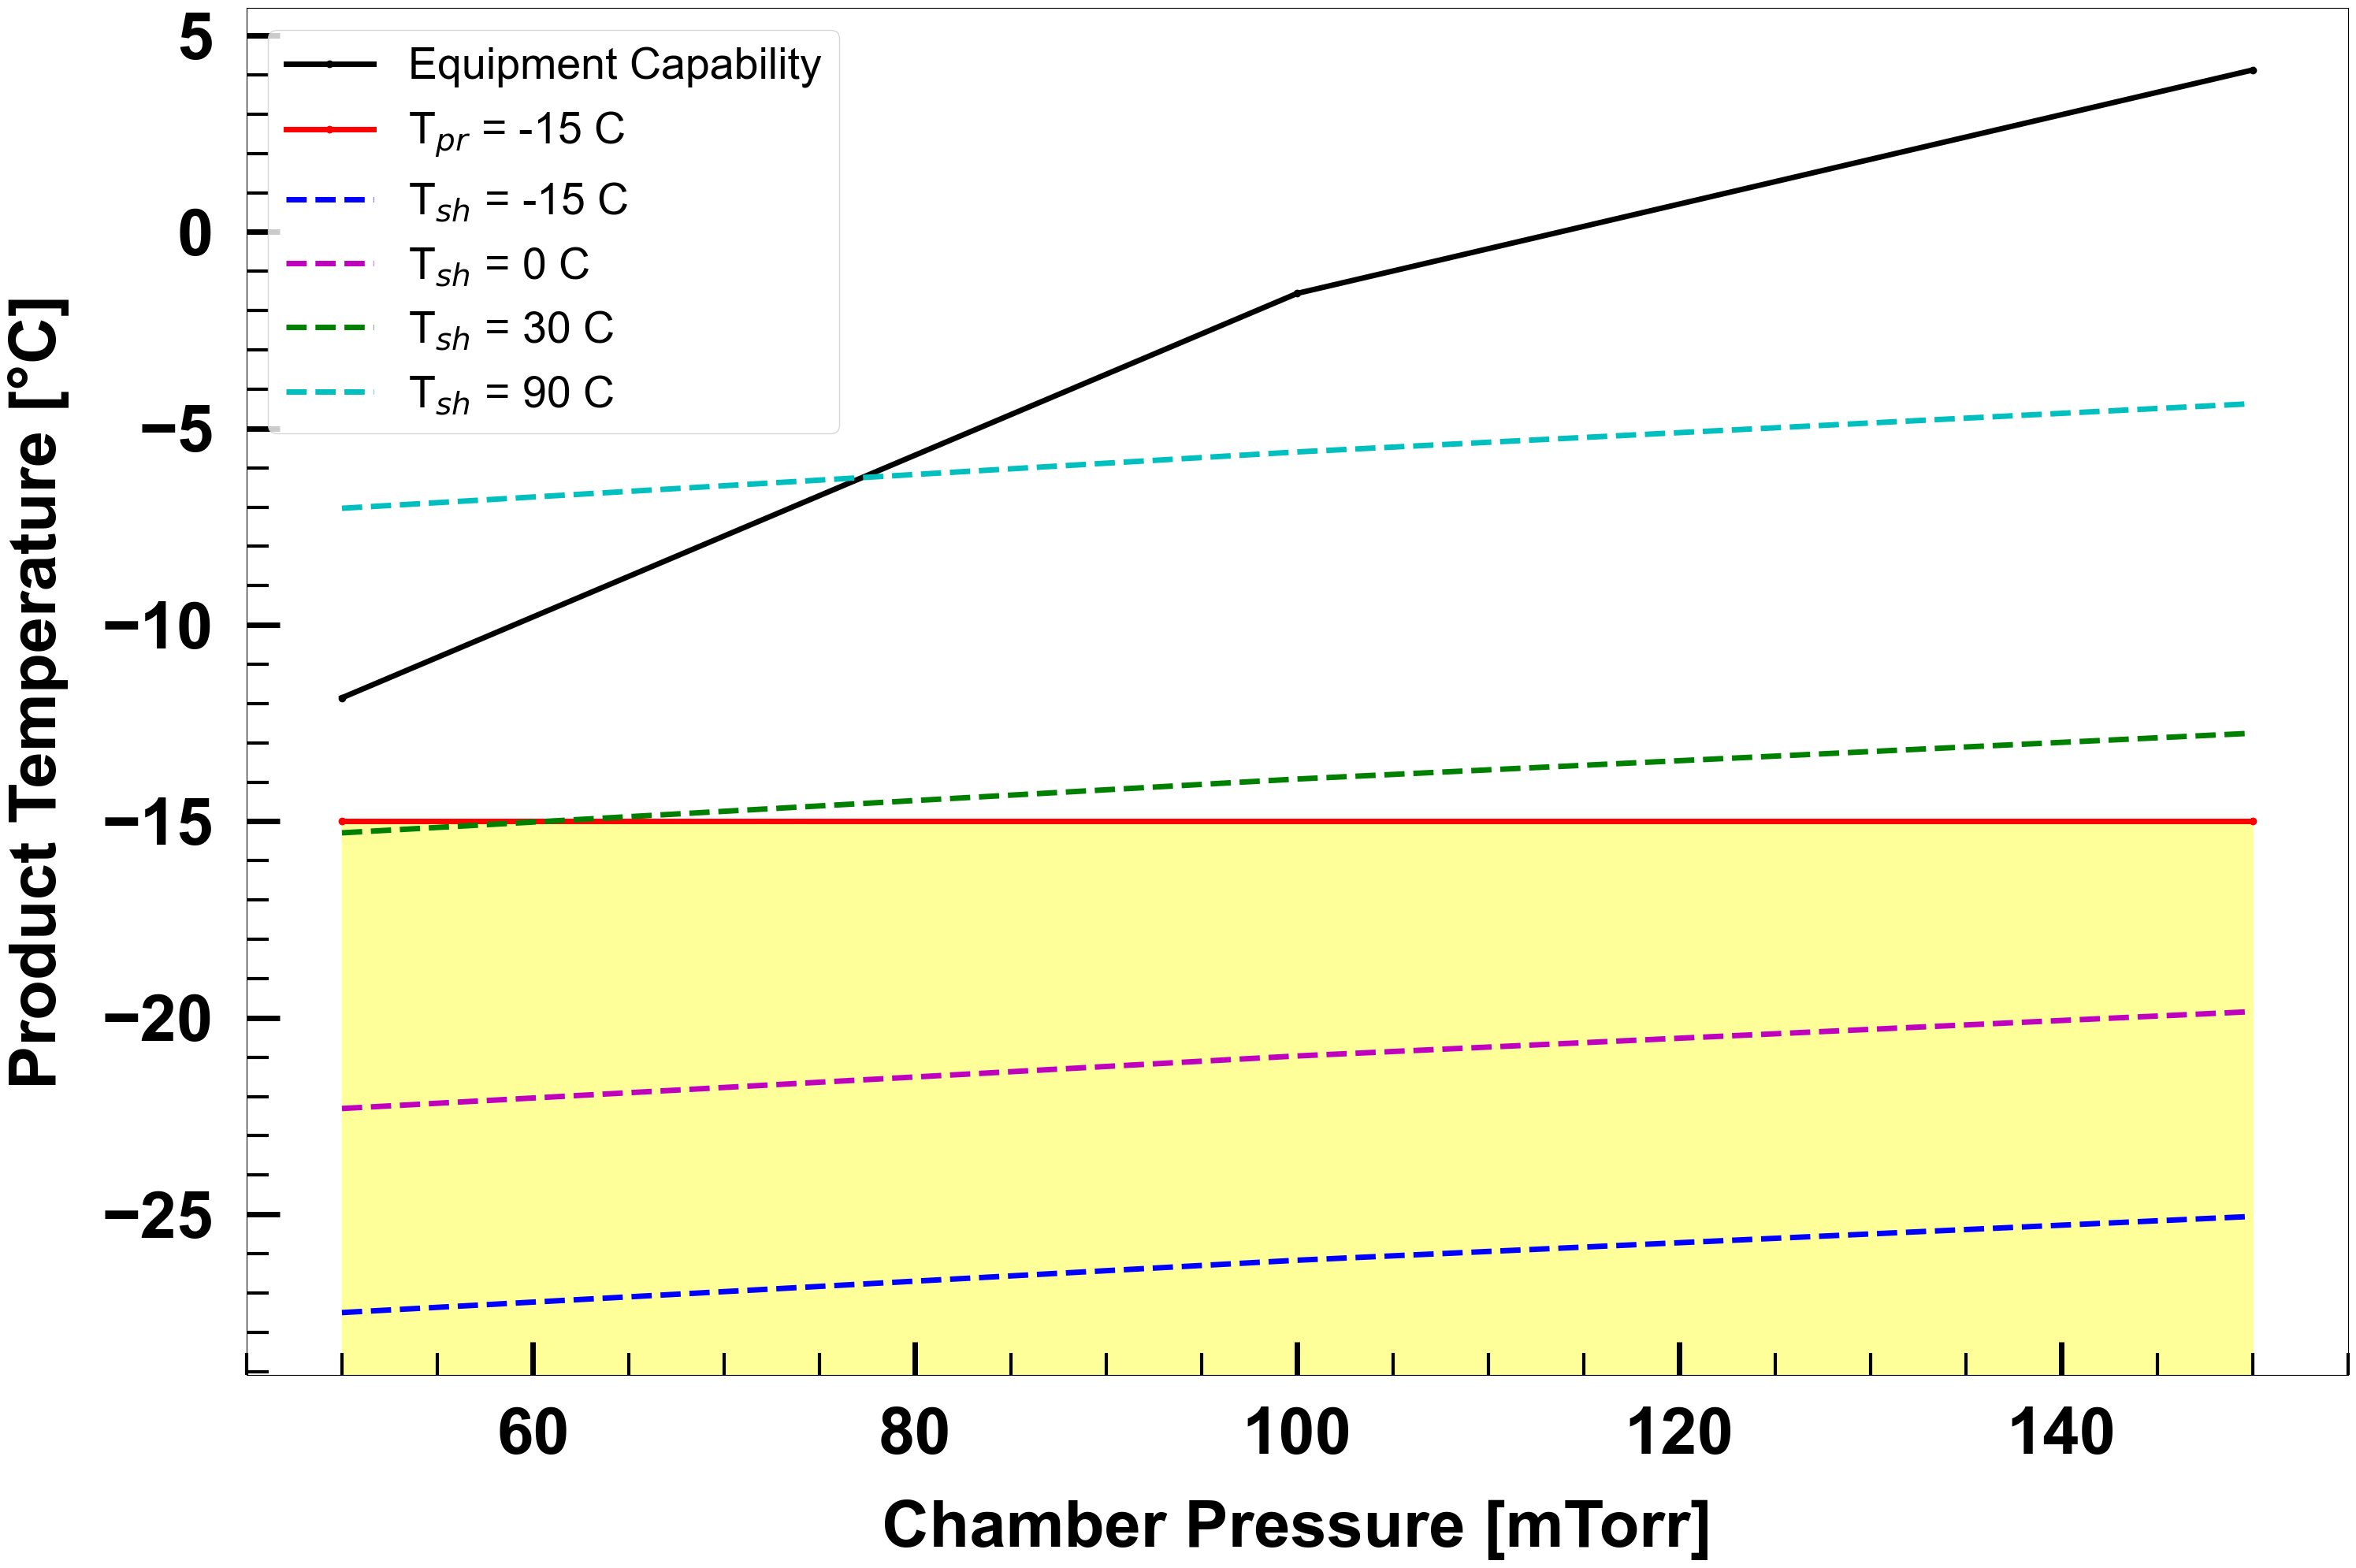

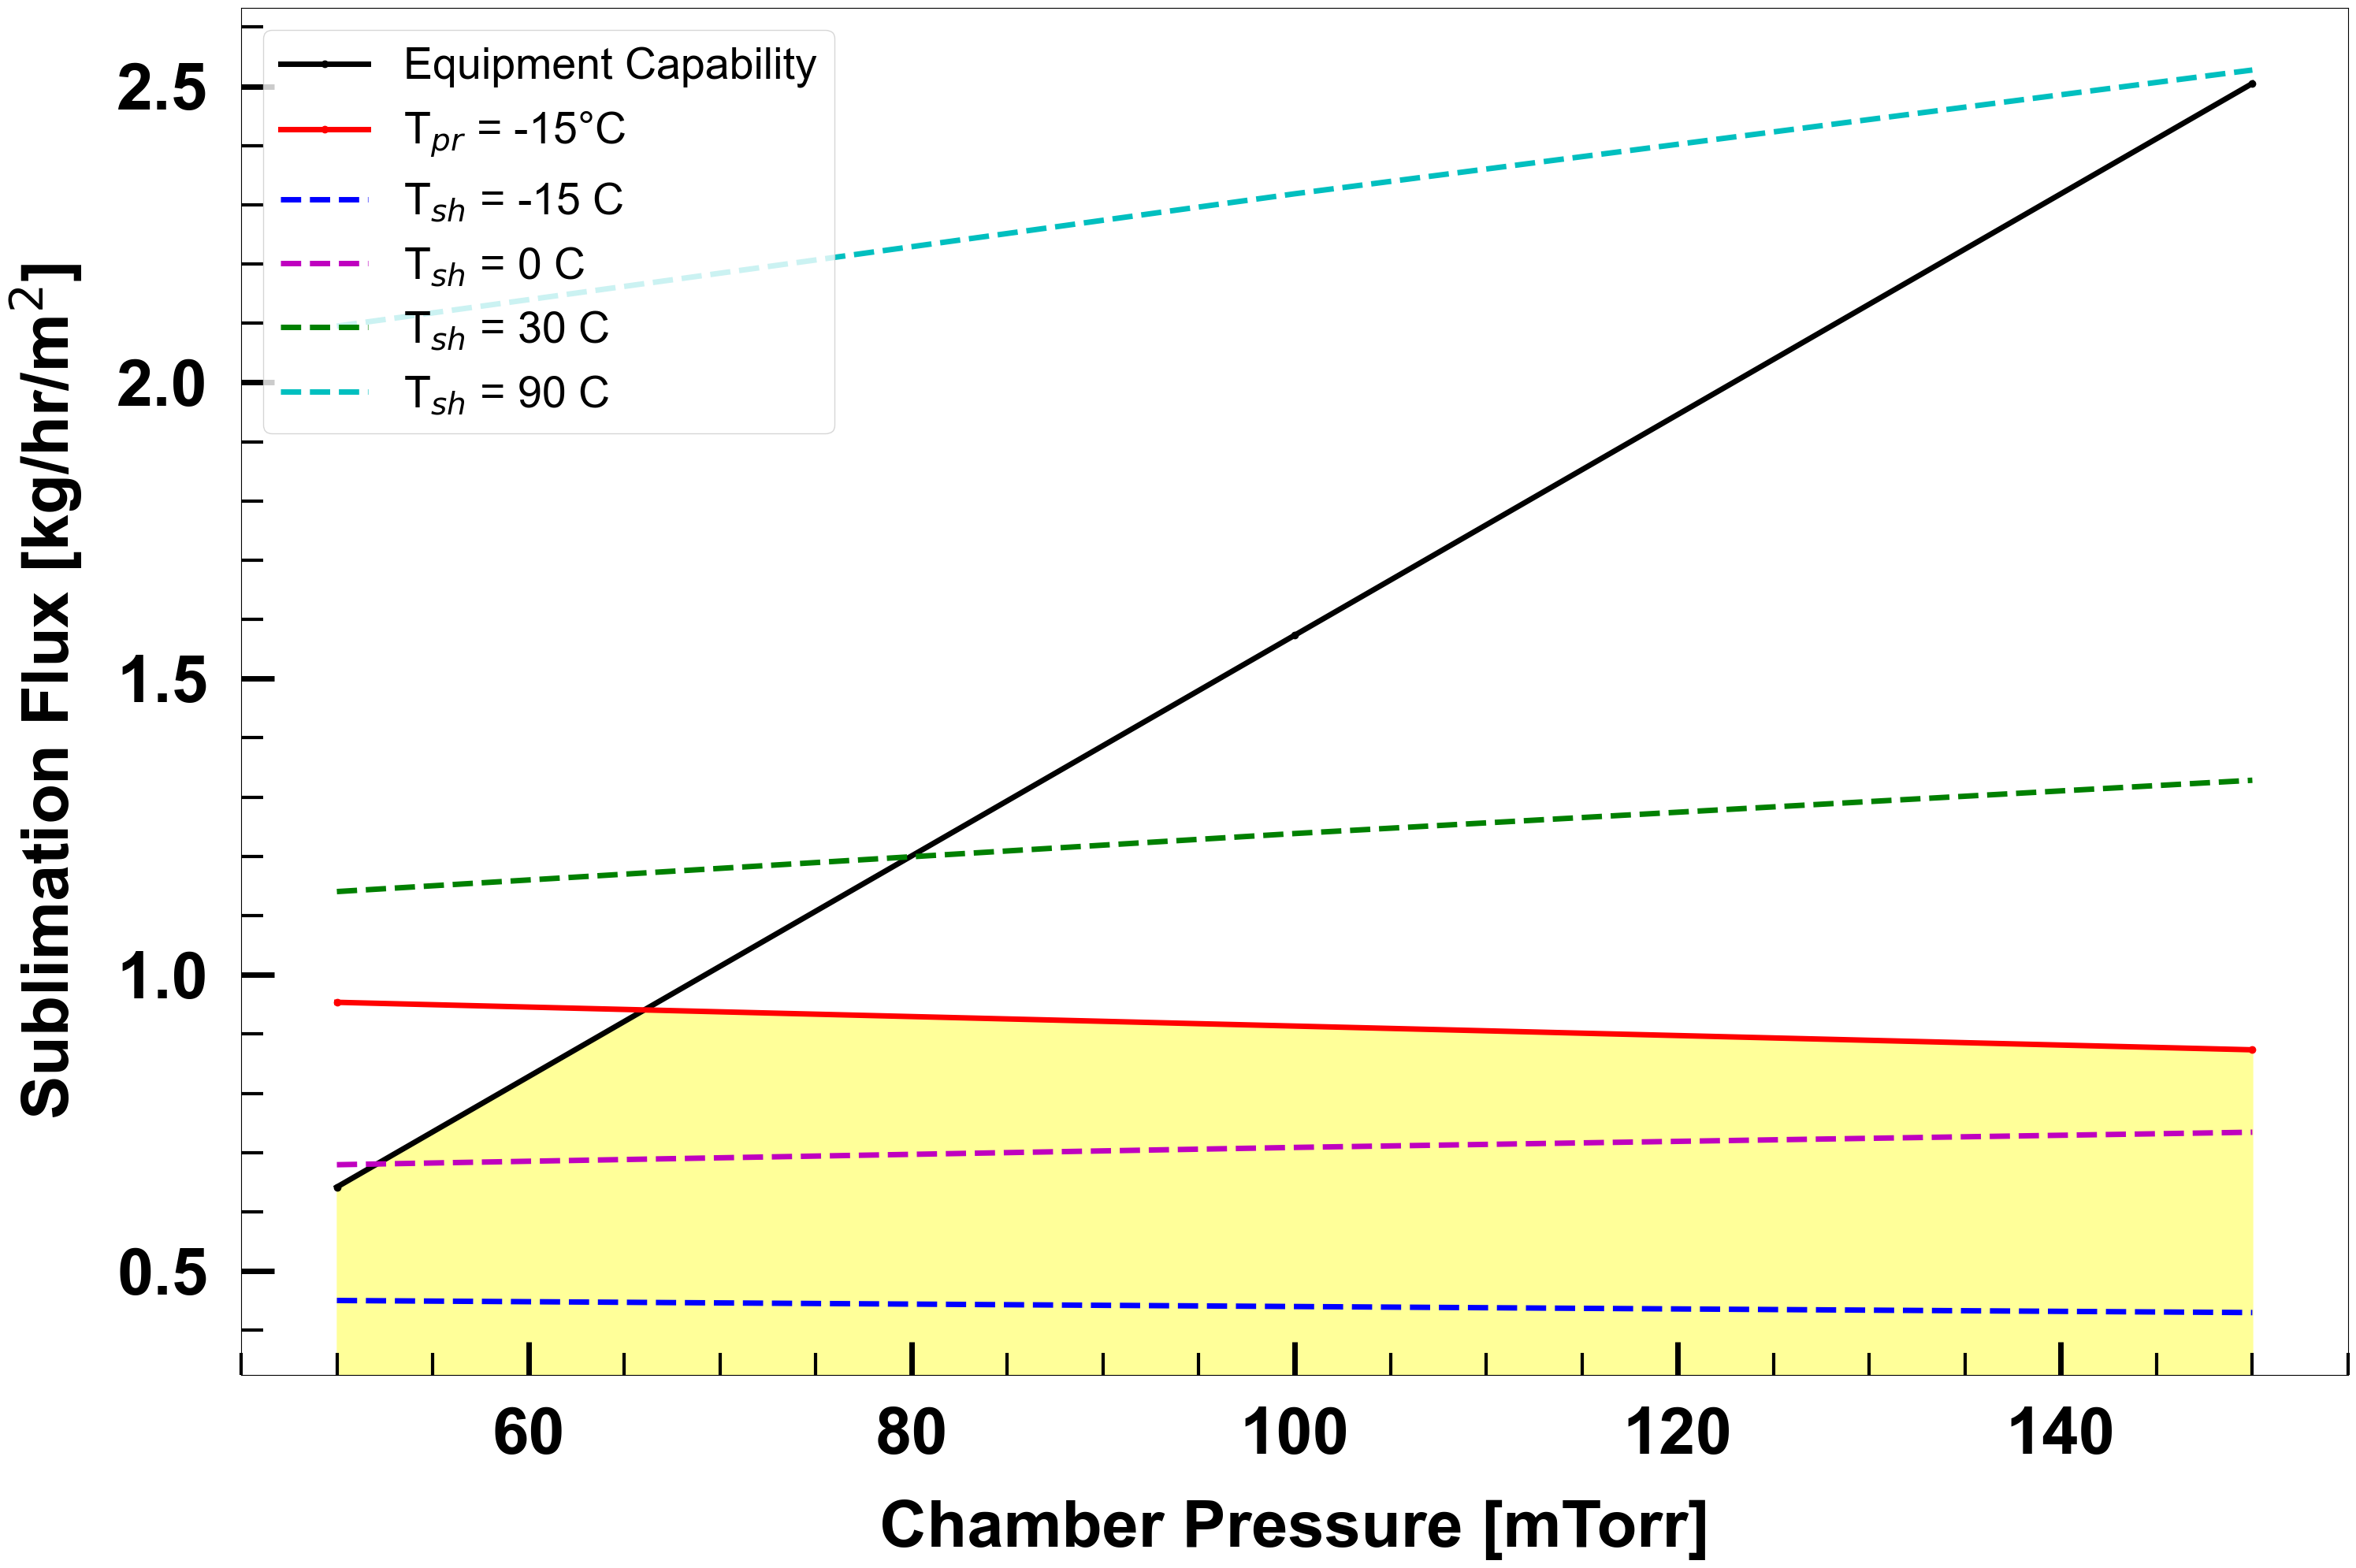

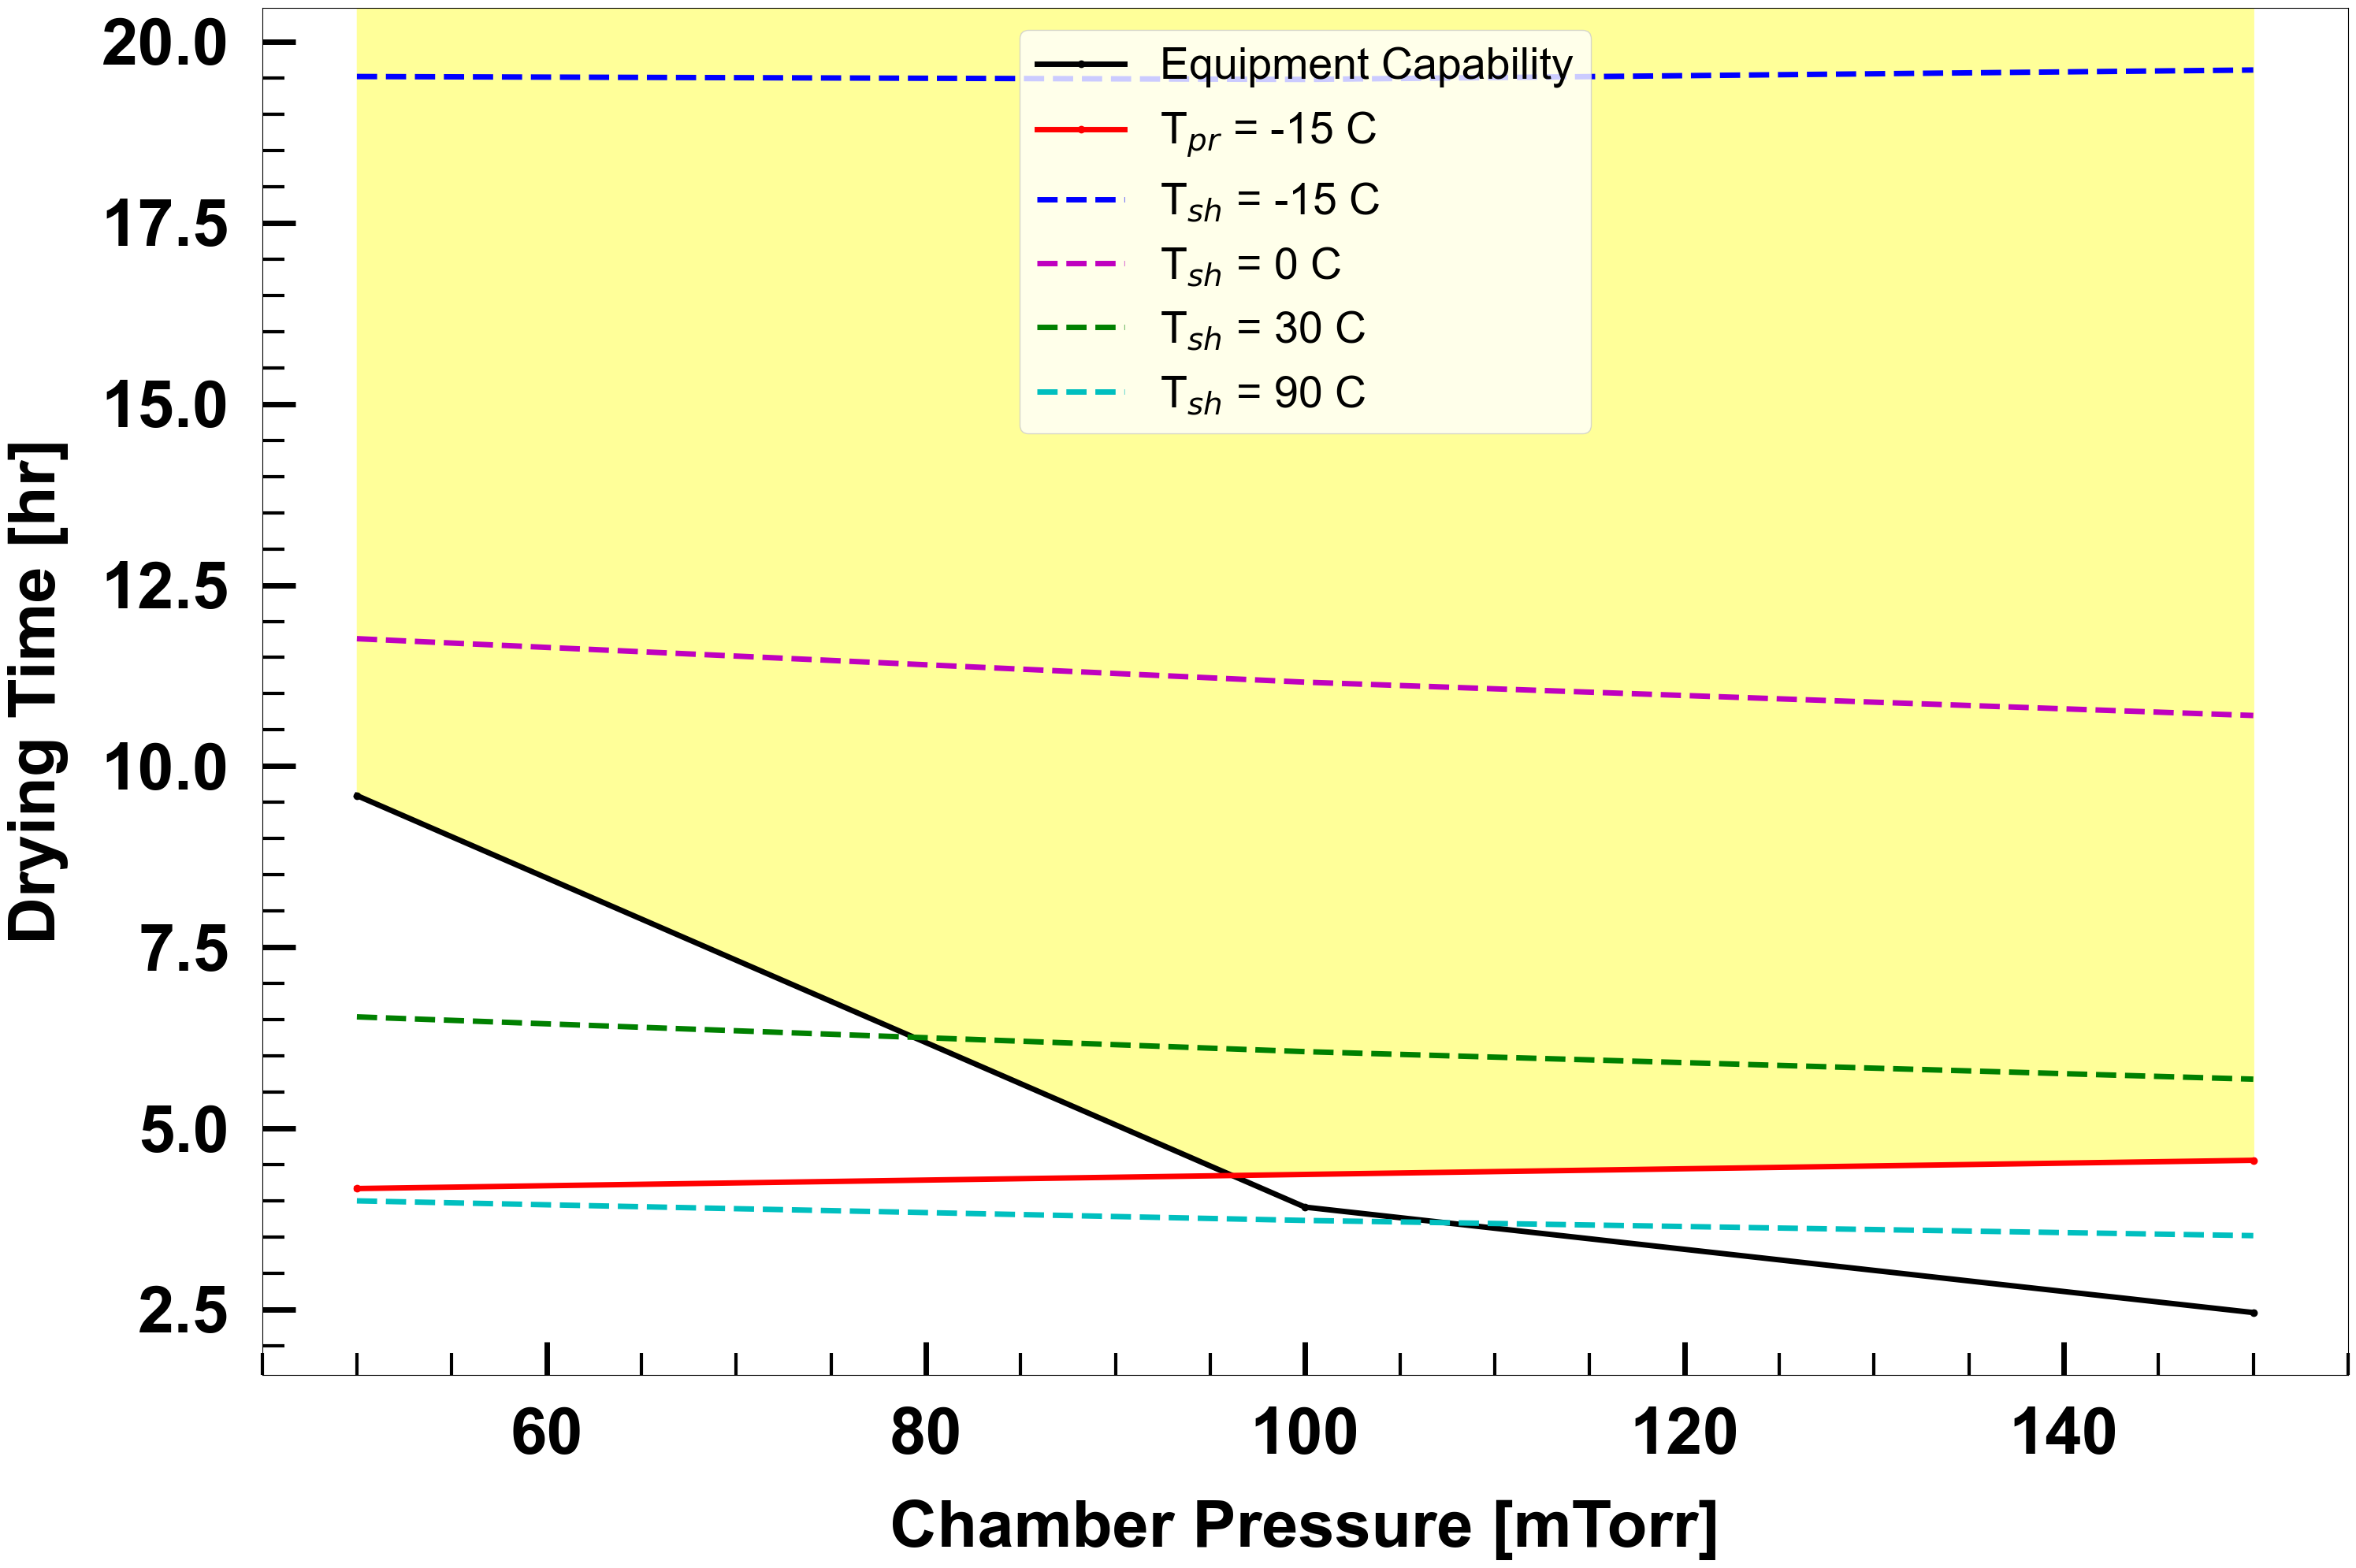

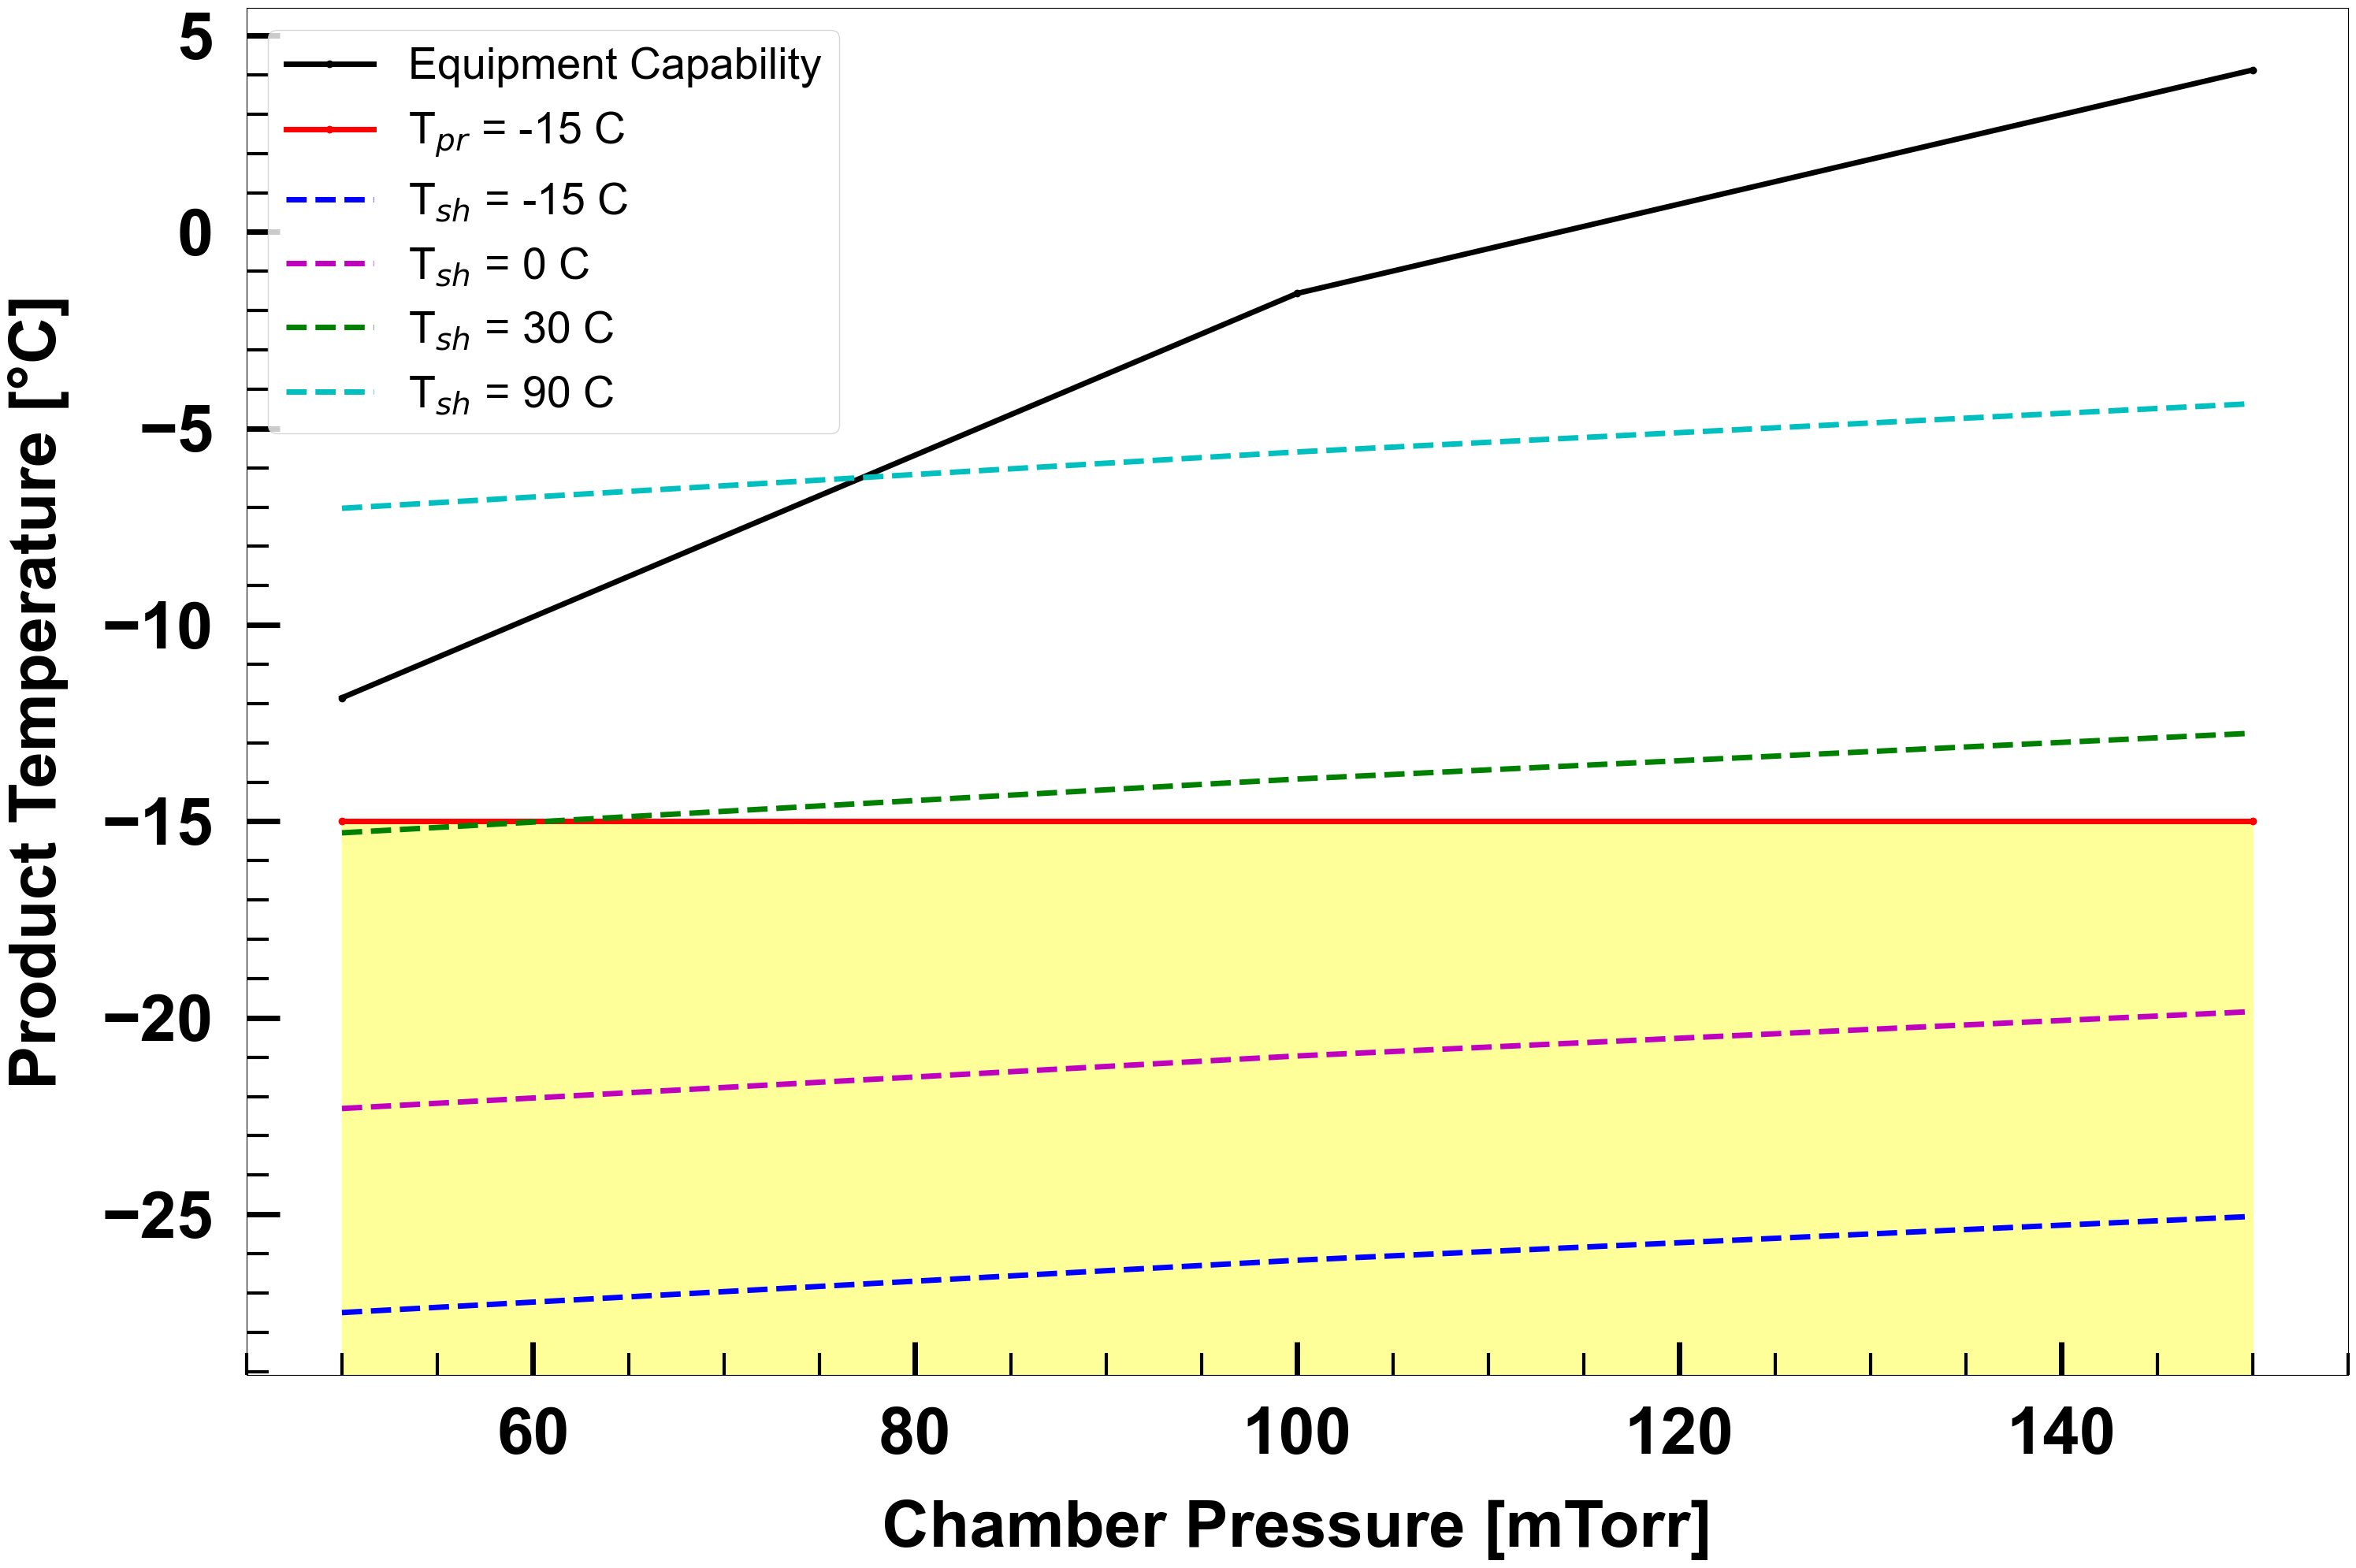

In [21]:
plots = generate_visualizations((ds_shelf, ds_pr, ds_eq_cap), sim_setup, "", save_figures=False) # Don't save to disk here, but you should in general

display(plots[0])
display(plots[1])
display(plots[2])
